# Day 3 · 逻辑回归——手写二分类

> 目标：理解 Sigmoid + 交叉熵，画出决策边界

> 前置：已学完 Day2 线性回归。逻辑回归的流程一模一样——只是换了预测函数和损失函数

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False
print("=─" * 20)
print("Day 3 · 逻辑回归——从回归到分类")
print("=─" * 20)

## 1. 准备数据

用 iris 数据集，只取前两类做二分类（setosa vs versicolor），只用前两个特征。

X shape: (100, 2), y shape: (100,)
类别: {np.int64(0), np.int64(1)} (其中 0=setosa, 1=versicolor)


d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site

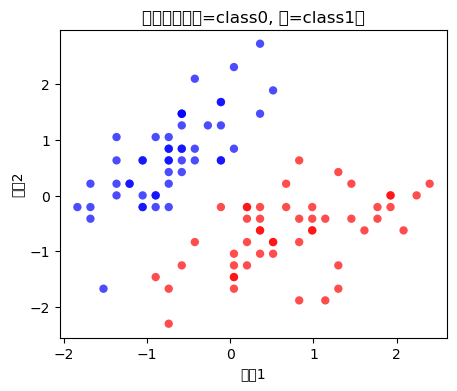

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris  # <--- 关键在这里

# 加载数据
iris = load_iris()
mask = iris.target < 2 
# ...后续代码保持不变...
X = iris.data[mask][:, :2]
y = iris.target[mask]

# 标准化（Day2 里没做，这里必须）
X = (X - X.mean(axis=0)) / X.std(axis=0)

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"类别: {set(y)} (其中 0=setosa, 1=versicolor)")

# 快速看一眼
plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr", alpha=0.7, edgecolors="none")
plt.xlabel("特征1"); plt.ylabel("特征2")
plt.title("原始数据（红=class0, 蓝=class1）")
plt.show()

## 2. 从线性回归到逻辑回归

**线性回归**：预测连续值

133\hat{y} = wx + b \quad 
ightarrow \quad (-∞, +∞)133

**逻辑回归**：预测概率（0~1）

133\hat{y} = \sigma(wx + b) \quad 
ightarrow \quad (0, 1)133

其中 Sigmoid 函数：

133\sigma(z) = 
rac{1}{1 + e^{-z}}133

d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


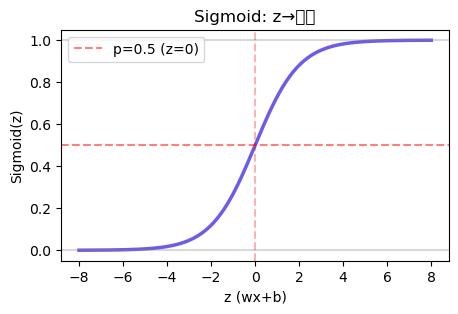

关键点:
  z=0 → p=0.5 (不确定)
  z→+∞ → p→1 (确定是 class 1)
  z→-∞ → p→0 (确定是 class 0)


In [2]:
def sigmoid(z):
    """把任意实数压缩到 (0, 1) 之间"""
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

# 画 Sigmoid 曲线
z = np.linspace(-8, 8, 200)
plt.figure(figsize=(5, 3))
plt.plot(z, sigmoid(z), "#6c5ce7", linewidth=2.5)
plt.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="p=0.5 (z=0)")
plt.axhline(0, color="gray", alpha=0.3); plt.axhline(1, color="gray", alpha=0.3)
plt.axvline(0, color="red", linestyle="--", alpha=0.3)
plt.xlabel("z (wx+b)"); plt.ylabel("Sigmoid(z)"); plt.legend()
plt.title("Sigmoid: z→概率"); plt.show()

print("关键点:")
print("  z=0 → p=0.5 (不确定)")
print("  z→+∞ → p→1 (确定是 class 1)")
print("  z→-∞ → p→0 (确定是 class 0)")

## 3. 交叉熵损失

线性回归用 MSE，为什么分类不能用？

因为 Sigmoid 后 MSE 会变成**非凸函数**，梯度下降会困在局部最低点。

交叉熵公式：

133J = -
rac{1}{m}\sum_{i=1}^{m} \left[ y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i) 
ight]133

> C++ 对照：就是如果真实标签=1，则只看 hBc\log(\hat{y})$；如果=0，只看 hBc\log(1-\hat{y})$。预测错误时惩罚很大。

In [3]:
# 快速感受交叉熵
y_pred_good = np.array([0.9, 0.1, 0.95, 0.05])  # 预测很羊确
y_true      = np.array([1,   0,   1,    0])
loss_good = -(y_true * np.log(y_pred_good) + (1-y_true) * np.log(1-y_pred_good)).mean()

y_pred_bad = np.array([0.1, 0.9, 0.05, 0.95])   # 预测全错
loss_bad = -(y_true * np.log(y_pred_bad) + (1-y_true) * np.log(1-y_pred_bad)).mean()

print(f"预测准确时损失: {loss_good:.4f}")
print(f"预测全错时损失: {loss_bad:.4f}")
print(f"→ 错误越大，损失越高，模型自然就往对的方向走")

预测准确时损失: 0.0783
预测全错时损失: 2.6492
→ 错误越大，损失越高，模型自然就往对的方向走


## 4. 手写逻辑回归（核心！）

和 Day2 一模一样的四步：前向 → 损失 → 梯度 → 更新

In [5]:
# 初始化
w = np.random.randn(2) * 0.01  # 这次2个特征，所以 w 有2个元素
b = 0.0
lr = 0.1
epochs = 5000
losses = []
m = len(y)

for epoch in range(epochs):
    # ① 前向: z = wx+b → sigmoid
    z = X @ w + b         # @ 是矩阵乘法，等价于 np.dot(X, w)
    y_pred = sigmoid(z)

    # ② 交叉熵损失
    eps = 1e-15  # 防止 log(0)
    loss = -(y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps)).mean()
    losses.append(loss)

    # ③ 梯度 (交叉熵 + sigmoid 合起来化简后跟 MSE 一样形式!)
    dw = (1 / m) * (X.T @ (y_pred - y))
    db = (1 / m) * (y_pred - y).sum()

    # ④ 更新参数
    w -= lr * dw
    b -= lr * db

    if epoch % 1000 == 0:
        acc = ((y_pred >= 0.5).astype(int) == y).mean()
        print(f"Epoch {epoch:4d}: loss={loss:.4f}, acc={acc:.3f}")

acc = ((y_pred >= 0.5).astype(int) == y).mean()
print(f"最终: w={w}, b={b:.3f}, acc={acc:.3f}")

Epoch    0: loss=0.6954, acc=0.260
Epoch 1000: loss=0.0399, acc=1.000
Epoch 2000: loss=0.0264, acc=1.000
Epoch 3000: loss=0.0207, acc=1.000
Epoch 4000: loss=0.0174, acc=1.000
最终: w=[ 6.3087224  -4.55938182], b=0.901, acc=1.000


## 5. 可视化：损失 曲线 + 决策边界

这是 Day3 最重要的图——看到那条线，就懂了逻辑回归在做什么。

D:\hyy\Temp\ipykernel_18124\2735631089.py:17: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig("day3_logistic.png", dpi=150, bbox_inches="tight"); plt.show()
D:\hyy\Temp\ipykernel_18124\2735631089.py:17: UserWarning: Glyph 21449 (\N{CJK UNIFIED IDEOGRAPH-53C9}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig("day3_logistic.png", dpi=150, bbox_inches="tight"); plt.show()
D:\hyy\Temp\ipykernel_18124\2735631089.py:17: UserWarning: Glyph 29109 (\N{CJK UNIFIED IDEOGRAPH-71B5}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig("day3_logistic.png", dpi=150, bbox_inches="tight"); plt.show()
D:\hyy\Temp\ipykernel_18124\2735631089.py:17: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig("day3_logistic.png", dpi=150, bbox_inches="tight"); plt.show()
D:\hyy\Temp\ipykernel_18124\2735631089.py:17: UserWarning: G

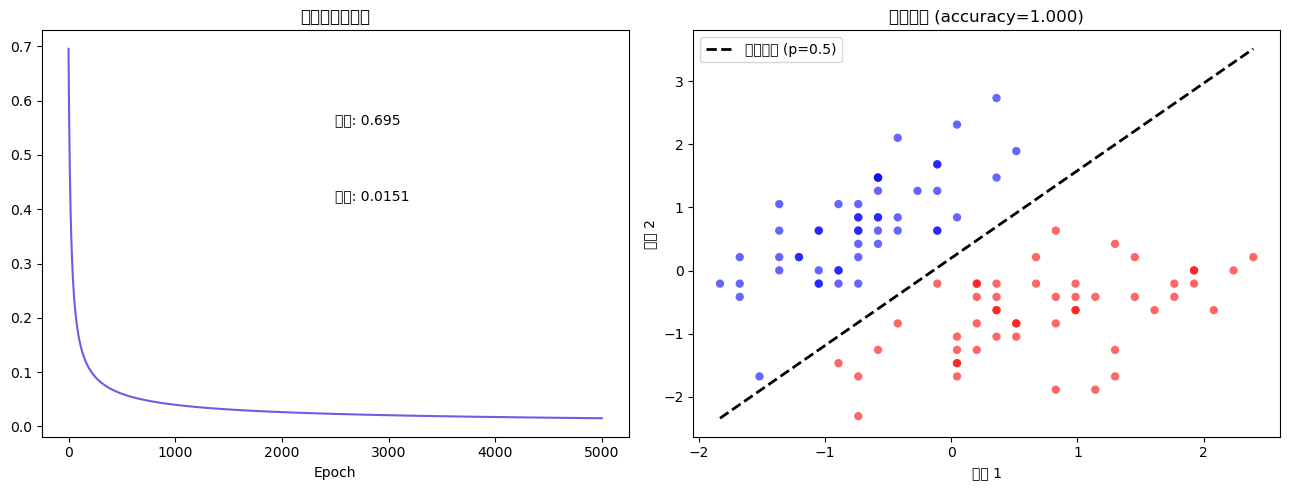

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左：损失曲线
axes[0].plot(losses, color="#6c5ce7")
axes[0].set_title("交叉熵损失曲线"); axes[0].set_xlabel("Epoch")
axes[0].text(epochs*0.5, losses[0]*0.8, f"初始: {losses[0]:.3f}", fontsize=10)
axes[0].text(epochs*0.5, losses[0]*0.6, f"最终: {losses[-1]:.4f}", fontsize=10)

# 右：决策边界
axes[1].scatter(X[:,0], X[:,1], c=y, cmap="bwr", alpha=0.6, edgecolors="none")
x1_range = np.linspace(X[:,0].min(), X[:,0].max(), 100)
x2_boundary = -(w[0] * x1_range + b) / w[1]  # wx+b=0.5 → 解出 x2
axes[1].plot(x1_range, x2_boundary, "k--", linewidth=2, label="决策边界 (p=0.5)")
axes[1].set_xlabel("特征 1"); axes[1].set_ylabel("特征 2")
axes[1].set_title(f"决策边界 (accuracy={acc:.3f})"); axes[1].legend()

plt.tight_layout(); plt.savefig("day3_logistic.png", dpi=150, bbox_inches="tight"); plt.show()

## 6. 用 sklearn 验证

In [7]:
from sklearn.linear_model import LogisticRegression

sk = LogisticRegression()
sk.fit(X, y)

print("== 参数对比 ==")
print(f"我们手写: w={w}, b={b:.4f}")
print(f"sklearn:    w={sk.coef_[0]}, b={sk.intercept_[0]:.4f}")
print(f"sklearn 准确率: {sk.score(X, y):.4f}")

== 参数对比 ==
我们手写: w=[ 6.3087224  -4.55938182], b=0.9012
sklearn:    w=[ 2.70731273 -2.2411063 ], b=0.2776
sklearn 准确率: 1.0000


# 🎉 Day 3 完成！

## 今天学到的

| 概念 | 一句话 | C++ 对照 |
|------|--------|------|
| **Sigmoid** | 把 (-∞,+∞) 压缩到 (0,1) |  |
| **交叉熵** | 分类专用损失，错误时惩罚很大 | 核心逻辑和 MSE 一样——计算误差 |
| **决策边界** | wx+b=0 这条线分开两类 |  |

## Day2 vs Day3

| | 线性回归 (Day2) | 逻辑回归 (Day3) |
|---|---|---|
| 预测函数 | ŷ=wx+b | ŷ=sigmoid(wx+b) |
| 损失函数 | MSE: Σ(ŷ-y)²/n | 交叉熵: -Σ[y·log(ŷ)+(1-y)log(1-ŷ)]/n |
| 梯度形式 | (2/n)Σx(ŷ-y) | (1/n)Σx(ŷ-y) **一模一样！** |
| 输出 | 连续值 | 0~1 概率 |

## 晚上作业

1. 把 iris 换成前两类、后两个特征，重跑一遍
2. 在纸上画 Sigmoid 曲线，标注 z=0 → p=0.5
3. 预习：多分类怎么办？搜 "Softmax"
